# 02 - Extração e Análise de Features

## Objetivo
Extrair features manuais de cada grão de café segmentado, organizando-as em uma tabela X (features) e um vetor y (rótulos).

### Famílias de features extraídas:
1. **Forma**: area, perímetro, circularidade, solidez, extensão, excentricidade
2. **Momentos de Hu**: 7 momentos invariantes (escala logarítmica)
3. **Cor**: médias e desvios padrão RGB e HSV
4. **Textura**: 4 propriedades GLCM (contrast, homogeneity, energy, correlation)

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from skimage.feature import graycomatrix, graycoprops

# Caminhos — detecta a raiz do projeto automaticamente
_cwd = Path('.').resolve()
if (_cwd / 'archive').is_dir():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / 'archive').is_dir():
    PROJECT_ROOT = _cwd.parent
else:
    raise FileNotFoundError("Não foi possível encontrar a pasta 'archive'. Execute o notebook a partir da raiz do projeto ou da pasta 'notebooks'.")

DATASET_DIR = PROJECT_ROOT / 'archive'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def imread_safe(path):
    """Lê imagem suportando caminhos com caracteres especiais (ex: acentos no Windows)."""
    data = np.fromfile(str(path), dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)

# Classes
classes = sorted([d for d in os.listdir(DATASET_DIR) if (DATASET_DIR / d).is_dir()])
print(f'{len(classes)} classes: {classes}')

17 classes: ['Broken', 'Cut', 'Dry Cherry', 'Fade', 'Floater', 'Full Black', 'Full Sour', 'Fungus Damange', 'Husk', 'Immature', 'Parchment', 'Partial Black', 'Partial Sour', 'Severe Insect Damange', 'Shell', 'Slight Insect Damage', 'Withered']


In [2]:
# Função de segmentação (mesma do notebook 01)
def segmentar_grao(img_bgr):
    """Segmenta o grão de café usando Otsu + maior contorno."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        mask_clean = np.zeros_like(mask)
        cv2.drawContours(mask_clean, [largest], -1, 255, -1)
        return mask_clean
    return mask

## Definição das funções de extração de features

In [6]:
def extrair_features_forma(mask):
    """Extrai features de forma a partir da máscara binária."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return [0] * 6
    
    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    
    # Circularidade: 4*pi*area / perimeter^2
    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
    
    # Solidez: area / area do convex hull
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0
    
    # Extensão: area / area do bounding rect
    x, y, w, h = cv2.boundingRect(cnt)
    rect_area = w * h
    extent = area / rect_area if rect_area > 0 else 0
    
    # Excentricidade: via elipse ajustada
    if len(cnt) >= 5:
        ellipse = cv2.fitEllipse(cnt)
        (_, (MA, ma), _) = ellipse
        # MA = eixo maior, ma = eixo menor
        a = max(MA, ma) / 2
        b = min(MA, ma) / 2
        eccentricity = np.sqrt(1 - (b**2 / a**2)) if a > 0 else 0
    else:
        eccentricity = 0
    
    return [area, perimeter, circularity, solidity, extent, eccentricity]

In [5]:
def extrair_momentos_hu(mask):
    """Extrai os 7 momentos de Hu em escala logarítmica."""
    moments = cv2.moments(mask)
    hu_moments = cv2.HuMoments(moments).flatten()
    # Escala logarítmica (com sinal preservado)
    hu_log = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)
    return hu_log.tolist()

In [11]:
def extrair_features_cor(img_bgr, mask):
    """Extrai features de cor (RGB e HSV) da região do grão."""
    # Converter para HSV
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    
    # Máscara booleana
    mask_bool = mask > 0
    
    features = []
    
    # Médias e desvios RGB
    for c in range(3):  # B, G, R
        channel = img_bgr[:, :, c]
        pixels = channel[mask_bool]
        if len(pixels) > 0:
            features.append(np.mean(pixels))
            features.append(np.std(pixels))
        else:
            features.extend([0, 0])
    
    # Médias e desvios HSV
    for c in range(3):  # H, S, V
        channel = img_hsv[:, :, c]
        pixels = channel[mask_bool]
        if len(pixels) > 0:
            features.append(np.mean(pixels))
            features.append(np.std(pixels))
        else:
            features.extend([0, 0])
    
    return features  # 12 features: mean_B, std_B, mean_G, std_G, mean_R, std_R, mean_H, std_H, mean_S, std_S, mean_V, std_V

In [7]:
def extrair_features_textura(img_bgr, mask):
    """Extrai features de textura via GLCM (Gray-Level Co-occurrence Matrix)."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # Aplicar máscara - pixels fora do grão ficam 0
    gray_masked = cv2.bitwise_and(gray, gray, mask=mask)
    
    # Recortar região de interesse (bounding box do grão)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return [0] * 4
    
    cnt = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)
    roi = gray_masked[y:y+h, x:x+w]
    
    if roi.size == 0 or roi.shape[0] < 2 or roi.shape[1] < 2:
        return [0] * 4
    
    # Calcular GLCM
    # Quantizar para 64 níveis para reduzir ruído
    roi_quantized = (roi // 4).astype(np.uint8)
    
    glcm = graycomatrix(roi_quantized, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=64, symmetric=True, normed=True)
    
    # Extrair propriedades (média das 4 direções)
    contrast = graycoprops(glcm, 'contrast').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()
    energy = graycoprops(glcm, 'energy').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    
    return [contrast, homogeneity, energy, correlation]

## Extração de features para todo o dataset

Processamos todas as imagens, extraindo o vetor completo de features para cada grão.

In [9]:
# Nomes das features
feature_names_forma = ['area', 'perimeter', 'circularity', 'solidity', 'extent', 'eccentricity']
feature_names_hu = [f'hu_{i}' for i in range(1, 8)]
feature_names_cor = ['mean_B', 'std_B', 'mean_G', 'std_G', 'mean_R', 'std_R',
                     'mean_H', 'std_H', 'mean_S', 'std_S', 'mean_V', 'std_V']
feature_names_textura = ['glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation']

all_feature_names = feature_names_forma + feature_names_hu + feature_names_cor + feature_names_textura
print(f'Total de features: {len(all_feature_names)}')
print(f'  Forma: {len(feature_names_forma)}')
print(f'  Hu: {len(feature_names_hu)}')
print(f'  Cor: {len(feature_names_cor)}')
print(f'  Textura: {len(feature_names_textura)}')

Total de features: 29
  Forma: 6
  Hu: 7
  Cor: 12
  Textura: 4


In [12]:
# Extrair features de todas as imagens
all_features = []
all_labels = []
all_filenames = []
erros = []

for cls in classes:
    img_paths = list((DATASET_DIR / cls).glob('*.jpg'))
    for img_path in img_paths:
        img = imread_safe(img_path)
        if img is None:
            erros.append(str(img_path))
            continue
        
        # Segmentar
        mask = segmentar_grao(img)
        
        # Verificar se segmentação foi válida
        if np.sum(mask > 0) < 100:  # muito poucos pixels
            erros.append(str(img_path))
            continue
        
        # Extrair features
        f_forma = extrair_features_forma(mask)
        f_hu = extrair_momentos_hu(mask)
        f_cor = extrair_features_cor(img, mask)
        f_textura = extrair_features_textura(img, mask)
        
        # Vetor completo
        feature_vector = f_forma + f_hu + f_cor + f_textura
        
        all_features.append(feature_vector)
        all_labels.append(cls)
        all_filenames.append(img_path.name)

print(f'Features extraídas: {len(all_features)} imagens')
print(f'Erros/falhas: {len(erros)} imagens')
if erros:
    print(f'  Exemplos: {erros[:5]}')

Features extraídas: 979 imagens
Erros/falhas: 0 imagens


In [13]:
# Criar DataFrames
X = pd.DataFrame(all_features, columns=all_feature_names)
y = pd.Series(all_labels, name='class')

print(f'Shape de X: {X.shape}')
print(f'Shape de y: {y.shape}')
print(f'\nDistribuição das classes:')
print(y.value_counts().sort_index())

# Verificar NaN ou infinitos
print(f'\nNaN em X: {X.isna().sum().sum()}')
print(f'Inf em X: {np.isinf(X.values).sum()}')

# Substituir possíveis NaN/inf
X = X.replace([np.inf, -np.inf], 0)
X = X.fillna(0)

Shape de X: (979, 29)
Shape de y: (979,)

Distribuição das classes:
class
Broken                   62
Cut                      66
Dry Cherry               54
Fade                     35
Floater                  48
Full Black               41
Full Sour                75
Fungus Damange           75
Husk                     53
Immature                 78
Parchment                54
Partial Black            65
Partial Sour             50
Severe Insect Damange    57
Shell                    57
Slight Insect Damage     55
Withered                 54
Name: count, dtype: int64

NaN em X: 0
Inf em X: 0


In [14]:
# Salvar X.csv e y.csv
X.to_csv(str(OUTPUT_DIR / 'X.csv'), index=False)
y.to_csv(str(OUTPUT_DIR / 'y.csv'), index=False)

print(f'Arquivos salvos:')
print(f'  {OUTPUT_DIR / "X.csv"}')
print(f'  {OUTPUT_DIR / "y.csv"}')
print(f'\nPrimeiras linhas de X:')
X.head()

Arquivos salvos:
  D:\Joao\Área de Trabalho\Projeto_Visao_Comp-main\outputs\X.csv
  D:\Joao\Área de Trabalho\Projeto_Visao_Comp-main\outputs\y.csv

Primeiras linhas de X:


,area,perimeter,circularity,solidity,extent,eccentricity,hu_1,hu_2,hu_3,hu_4,...,mean_H,std_H,mean_S,std_S,mean_V,std_V,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation
0,44837.5,1117.418390,0.451253,0.945829,0.725808,0.810271,3.140350,6.936113,9.991111,9.999923,...,18.555475,4.794859,88.778344,36.869107,155.412646,17.927129,23.724930,0.731929,0.271896,0.952042
1,38073.5,888.648836,0.605860,0.966651,0.631684,0.892303,3.078954,6.523761,9.984520,9.997515,...,21.937172,13.122244,47.653170,12.667491,168.199355,16.694770,22.701706,0.834303,0.367434,0.969160
2,32023.5,733.109733,0.748757,0.988502,0.660278,0.841220,3.131568,6.850319,9.924289,9.995808,...,16.238612,1.925306,114.674429,27.917121,157.510344,11.932243,20.000353,0.718904,0.336321,0.958413
3,32069.5,735.050858,0.745877,0.981935,0.637438,0.831041,3.132614,6.839260,9.958282,9.997442,...,18.770314,11.023015,76.635813,34.822300,192.521449,11.810310,24.264154,0.813644,0.367951,0.971980
4,38013.0,744.925968,0.860827,0.991924,0.786791,0.530797,3.196363,7.922342,9.984960,9.999895,...,19.601335,3.362623,69.623481,19.131443,167.997392,10.061784,22.440837,0.716023,0.247730,0.952751


## Análise exploratória das features

### Estatísticas descritivas

In [11]:
# Estatísticas descritivas
X.describe().T

,count,mean,std,min,25%,50%,75%,max
area,979.0,32243.802860,14143.158914,8643.000000,22947.750000,28595.500000,37489.500000,104891.500000
perimeter,979.0,723.998548,176.501117,382.877198,605.340182,677.872145,808.686898,2241.831724
circularity,979.0,0.761821,0.117488,0.128498,0.717095,0.802724,0.843036,0.890137
solidity,979.0,0.971038,0.034718,0.592001,0.968852,0.983091,0.988728,0.993958
extent,979.0,0.724451,0.059520,0.345574,0.704839,0.736061,0.763582,0.831403
eccentricity,979.0,0.659028,0.139922,0.162130,0.585172,0.670947,0.748844,0.960706
hu_1,979.0,3.168873,0.040380,2.867542,3.163204,3.182107,3.192318,3.204290
hu_2,979.0,7.481713,0.569916,5.869373,7.149242,7.436405,7.753787,9.727941
hu_3,979.0,9.973522,0.054010,9.426652,9.976703,9.991391,9.996804,9.999996
hu_4,979.0,9.996939,0.014482,9.723252,9.999069,9.999858,9.999965,10.000000


### Boxplots por classe - Features de Forma

C:\Users\JoãoAntoniodeSouzaVi\AppData\Local\Temp\ipykernel_23256\439082359.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=7)
C:\Users\JoãoAntoniodeSouzaVi\AppData\Local\Temp\ipykernel_23256\439082359.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=7)
C:\Users\JoãoAntoniodeSouzaVi\AppData\Local\Temp\ipykernel_23256\439082359.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=7)
C:\Users\JoãoAntoniodeSouzaVi\AppData\Local\Temp\ipykernel_23256\439082359.py:11: UserWarning: set_t

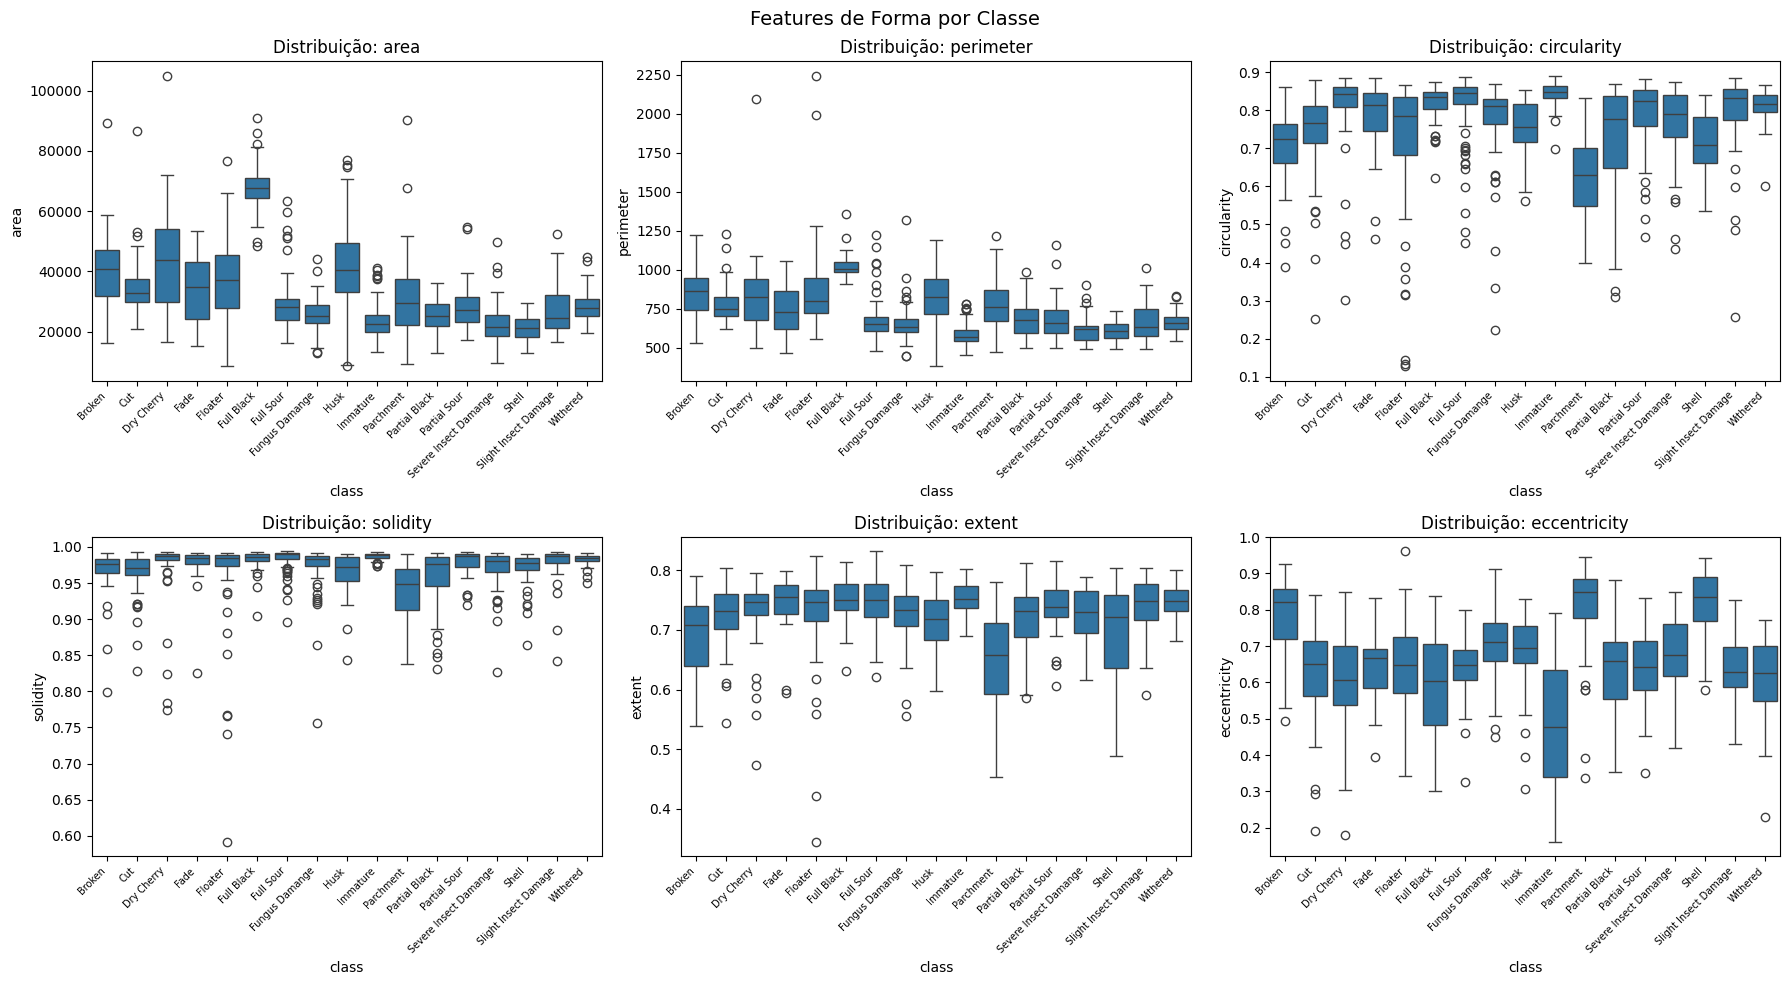

In [12]:
# Boxplots - Features de Forma
df_plot = X[feature_names_forma].copy()
df_plot['class'] = y.values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feat in enumerate(feature_names_forma):
    sns.boxplot(data=df_plot, x='class', y=feat, ax=axes[i])
    axes[i].set_title(f'Distribuição: {feat}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.suptitle('Features de Forma por Classe', fontsize=14)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'boxplot_forma.png'), dpi=150, bbox_inches='tight')
plt.show()

### Boxplots por classe - Features de Cor

C:\Users\JoãoAntoniodeSouzaVi\AppData\Local\Temp\ipykernel_23256\748623034.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=7)
C:\Users\JoãoAntoniodeSouzaVi\AppData\Local\Temp\ipykernel_23256\748623034.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=7)
C:\Users\JoãoAntoniodeSouzaVi\AppData\Local\Temp\ipykernel_23256\748623034.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=7)
C:\Users\JoãoAntoniodeSouzaVi\AppData\Local\Temp\ipykernel_23256\748623034.py:12: UserWarning: set_t

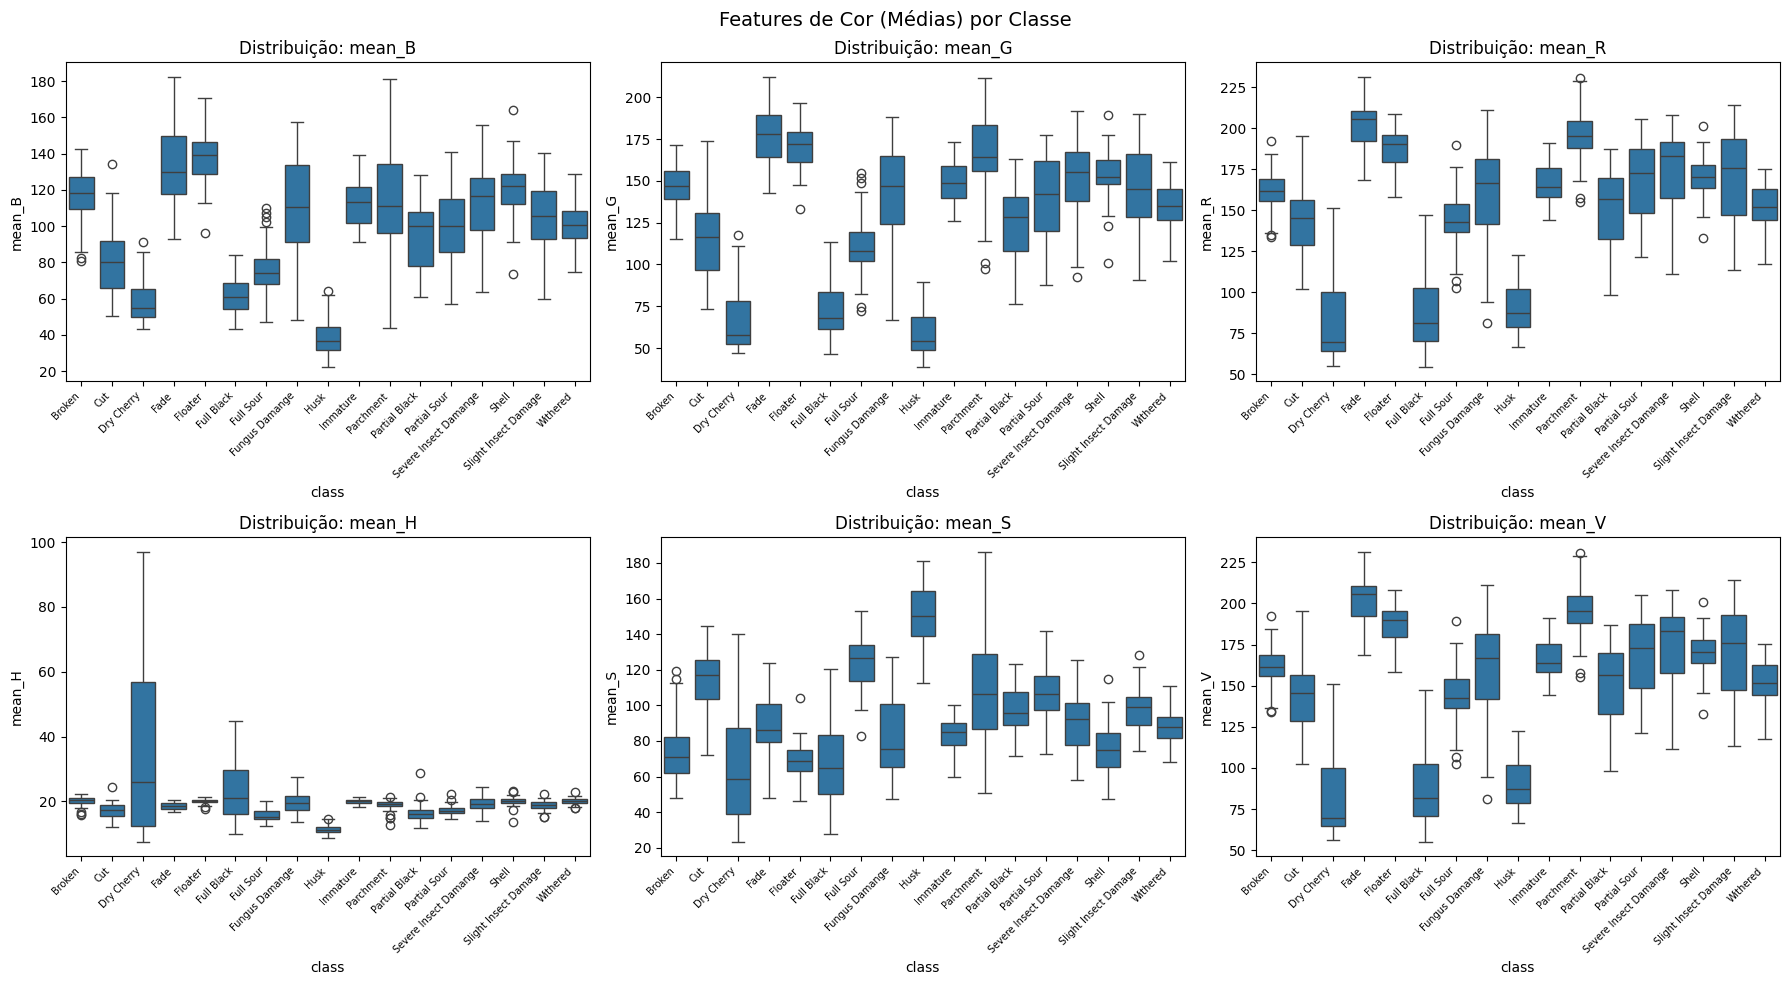

In [13]:
# Boxplots - Features de Cor (médias apenas, para clareza)
cor_medias = ['mean_B', 'mean_G', 'mean_R', 'mean_H', 'mean_S', 'mean_V']
df_plot_cor = X[cor_medias].copy()
df_plot_cor['class'] = y.values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feat in enumerate(cor_medias):
    sns.boxplot(data=df_plot_cor, x='class', y=feat, ax=axes[i])
    axes[i].set_title(f'Distribuição: {feat}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.suptitle('Features de Cor (Médias) por Classe', fontsize=14)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'boxplot_cor.png'), dpi=150, bbox_inches='tight')
plt.show()

### Boxplots por classe - Features de Textura

C:\Users\JoãoAntoniodeSouzaVi\AppData\Local\Temp\ipykernel_23256\3797052964.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=7)
C:\Users\JoãoAntoniodeSouzaVi\AppData\Local\Temp\ipykernel_23256\3797052964.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=7)
C:\Users\JoãoAntoniodeSouzaVi\AppData\Local\Temp\ipykernel_23256\3797052964.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=7)
C:\Users\JoãoAntoniodeSouzaVi\AppData\Local\Temp\ipykernel_23256\3797052964.py:11: UserWarning: s

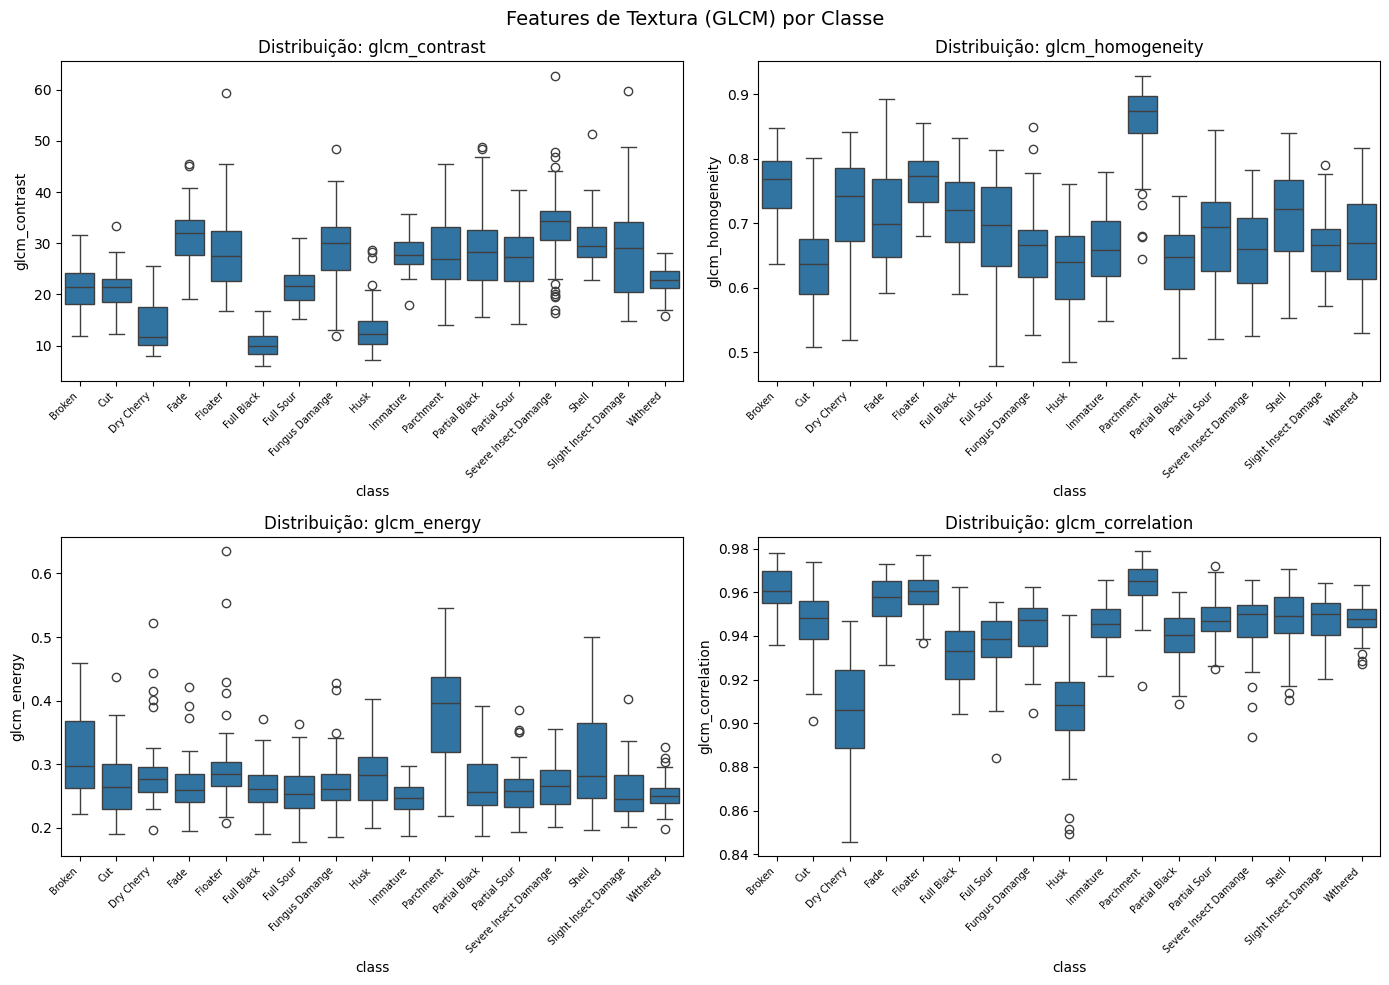

In [14]:
# Boxplots - Features de Textura
df_plot_tex = X[feature_names_textura].copy()
df_plot_tex['class'] = y.values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feat in enumerate(feature_names_textura):
    sns.boxplot(data=df_plot_tex, x='class', y=feat, ax=axes[i])
    axes[i].set_title(f'Distribuição: {feat}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.suptitle('Features de Textura (GLCM) por Classe', fontsize=14)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'boxplot_textura.png'), dpi=150, bbox_inches='tight')
plt.show()

### Matriz de correlação entre features

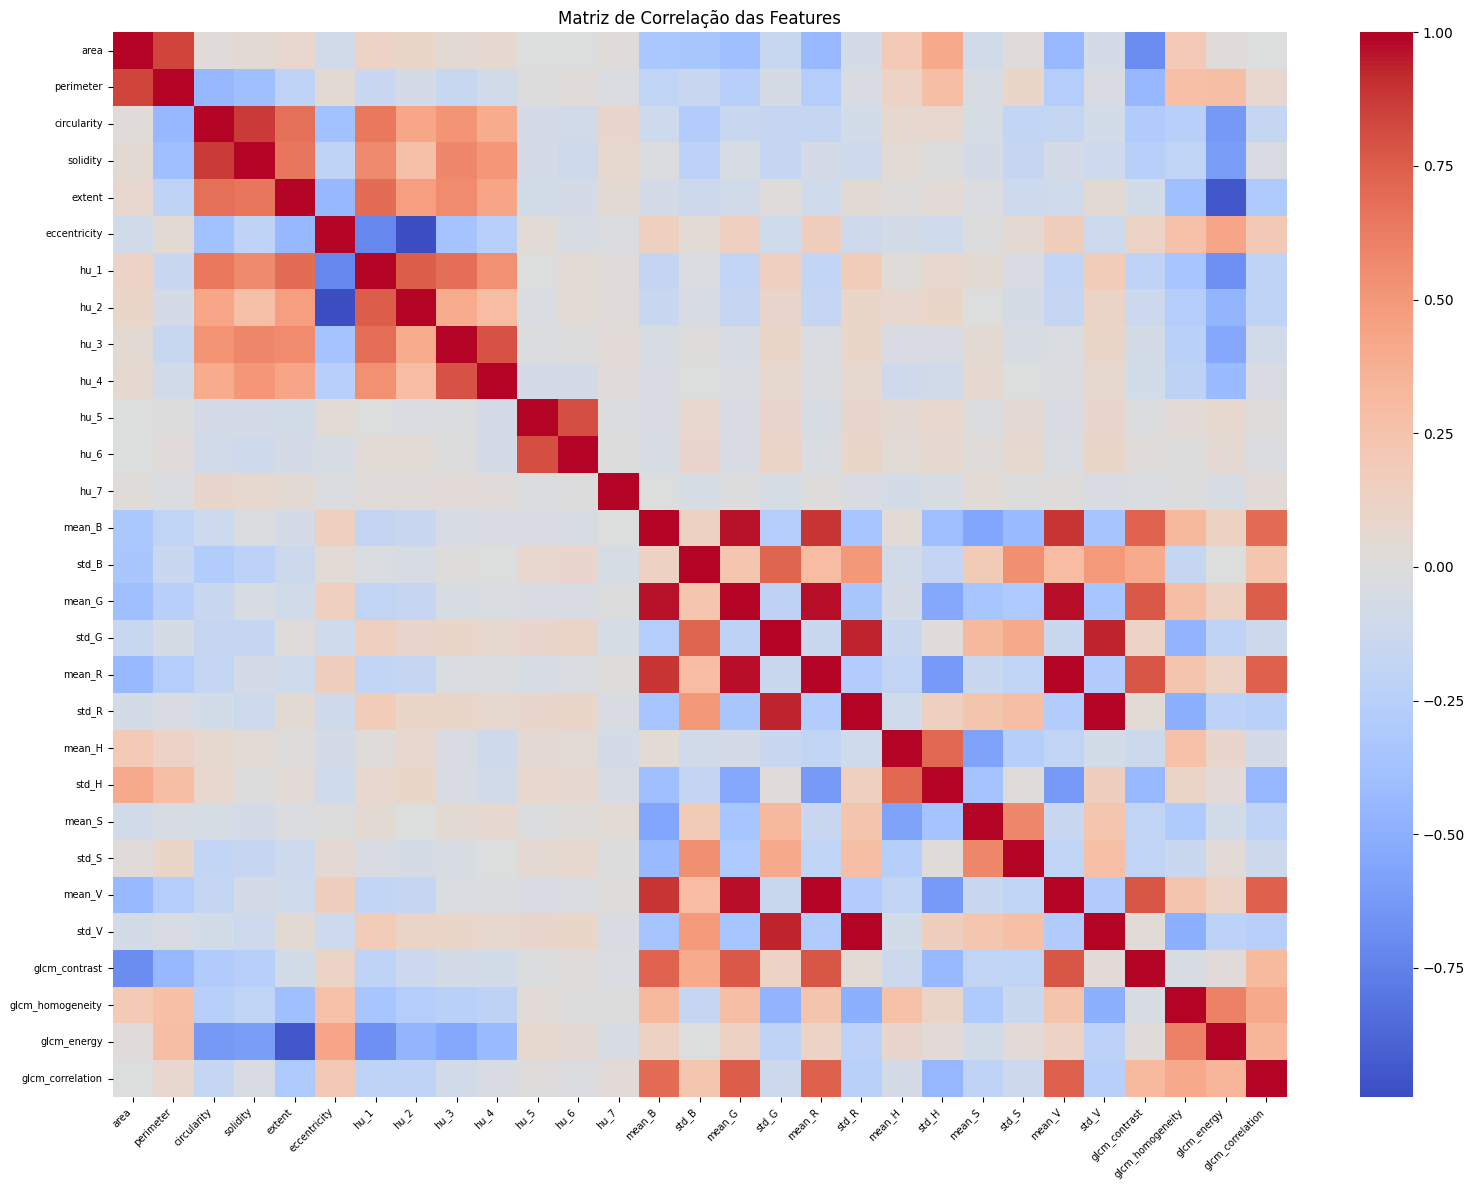

In [15]:
# Matriz de correlação
plt.figure(figsize=(16, 12))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            xticklabels=all_feature_names, yticklabels=all_feature_names)
plt.title('Matriz de Correlação das Features')
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'correlacao_features.png'), dpi=150, bbox_inches='tight')
plt.show()

### Médias por classe - Comparação visual

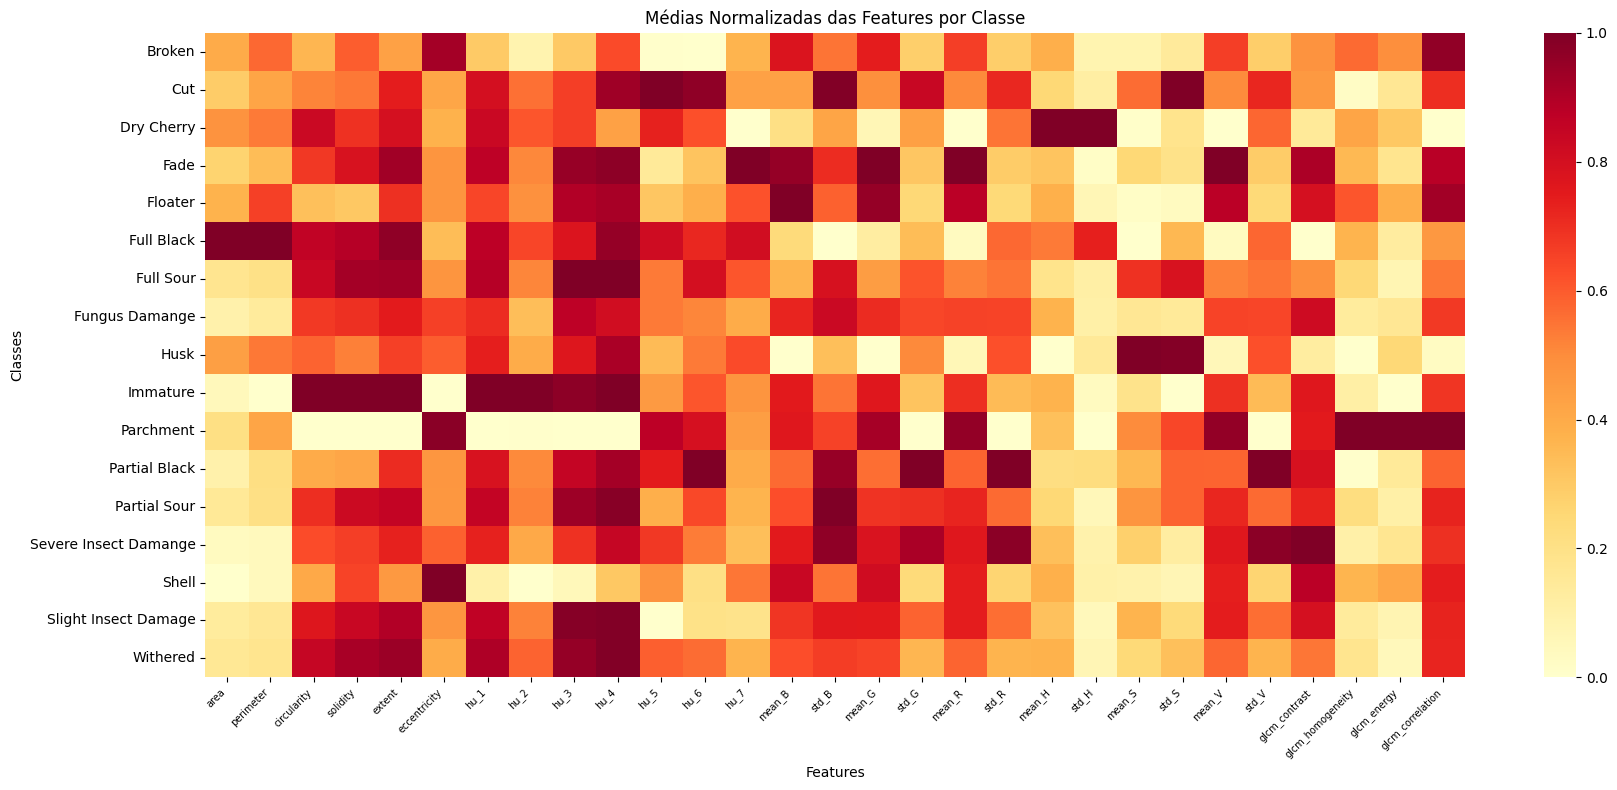

In [16]:
# Médias por classe para features selecionadas
df_full = X.copy()
df_full['class'] = y.values

medias_classe = df_full.groupby('class').mean()

# Heatmap de médias normalizadas
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
medias_norm = pd.DataFrame(
    scaler.fit_transform(medias_classe),
    index=medias_classe.index,
    columns=medias_classe.columns
)

plt.figure(figsize=(18, 8))
sns.heatmap(medias_norm, cmap='YlOrRd', annot=False)
plt.title('Médias Normalizadas das Features por Classe')
plt.xlabel('Features')
plt.ylabel('Classes')
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'medias_por_classe.png'), dpi=150, bbox_inches='tight')
plt.show()

## Comentários sobre as features

### Quais features parecem separar melhor as classes?

Com base nos boxplots e na análise visual:

1. **Cor (mean_H, mean_S, mean_V)**: Diferentes defeitos apresentam colorações distintas. Grãos pretos (Full Black) têm valor (V) baixo; grãos imaturos têm matiz (H) diferenciada; grãos com fungos têm saturação alterada.

2. **Forma (area, circularity, solidity)**: Grãos quebrados (Broken, Shell) tendem a ter menor área e circularidade diferente de grãos inteiros. A solidez distingue grãos com concavidades (Cut, Husk).

3. **Textura (GLCM contrast, homogeneity)**: Grãos com danos de inseto ou fungo apresentam textura mais irregular (maior contraste, menor homogeneidade).

4. **Momentos de Hu**: Capturam diferenças de forma global (simetria, elongação) que ajudam a distinguir Shell/Husk de grãos inteiros.

### Conclusão
O vetor de 29 features captura informação complementar de forma, cor e textura, adequado para o problema de classificação de defeitos em grãos de café.

In [17]:
print('Notebook 02 concluído.')
print(f'X.csv salvo com shape {X.shape}')
print(f'y.csv salvo com {len(y)} rótulos de {y.nunique()} classes')

Notebook 02 concluído.
X.csv salvo com shape (979, 29)
y.csv salvo com 979 rótulos de 17 classes
